# Assignment-17
### Project 3: Bike Rental Demand Prediction

Dataset: https://drive.google.com/file/d/1-v1qhOk08UVUBKhFqqp2kM8Dx4y5pfSE/view?usp=sharing

Overview
In this project, you will build a Decision Tree Regression model to predict the number of bike rentals based on weather and seasonal conditions. This helps understand how environmental factors influence urban mobility demand.

Tasks
1. Load dataset in Python.
2. Use features: temp, humidity, windspeed, season.
3. Target variable: count of bike rentals.
4. Clean and preprocess the data (handle missing values, encode categorical variables if needed).
5. Train a Decision Tree Regressor model.
6. Predict bike rental demand for a custom input:
 - temp = 0.5
 - humidity = 0.6
 - windspeed = 0.2
 - season = 3
Explain your predicted result in one or two lines.

### library import

In [239]:
import  numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [240]:
data=pd.read_csv("/kaggle/input/datasets/nvnkhan/bike-rental-system/bike_rental_100_rows.csv")

# understanding datasets
- 100 rows
- no missing values
- no duplicate values

In [241]:
data.head(2)

,temp,humidity,windspeed,season,count
0,0.40,0.87,0.37,1,31
1,0.22,0.31,0.03,4,191


In [242]:

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   temp       100 non-null    float64
 1   humidity   100 non-null    float64
 2   windspeed  100 non-null    float64
 3   season     100 non-null    int64  
 4   count      100 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.0 KB


In [243]:
data.duplicated().sum()

np.int64(0)

# Model developement

In [244]:
X=data.iloc[:,0:4]
Y=data.iloc[:,-1]

# split data set
X_train,X_test,y_train,y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42
)
# Model development
model=DecisionTreeRegressor(
               ccp_alpha=0.8,    
)
model.fit(X_train,y_train)

prediction_result=model.predict(X_test)

# Model Evalution

In [245]:
MSE=mean_squared_error(y_test,prediction_result)
MAE=mean_absolute_error(y_test,prediction_result)
r2=r2_score(y_test,prediction_result)

print("MSE",MSE)

print("MAE",MAE)

print("R2_Score",r2)


MSE 1269.6277777777777
MAE 27.45
R2_Score 0.894390774053291


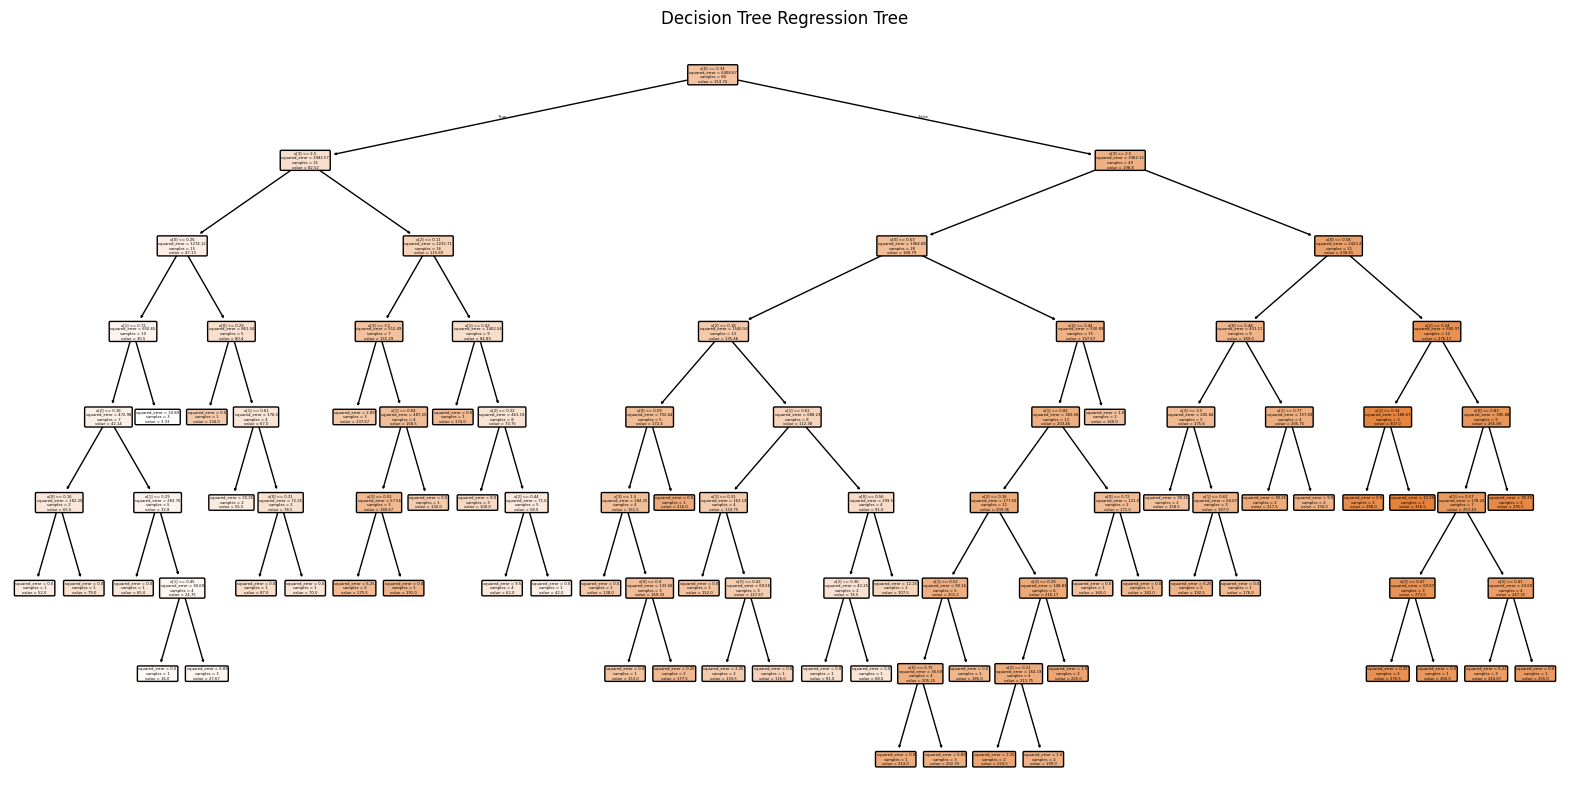

In [247]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plot_tree(model, 
        
          filled=True, 
          rounded=True,
          precision=2)
plt.title("Decision Tree Regression Tree")
plt.show()
